In [1]:
# import helper packages
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# check the versions of tensorflow, pytorch and keras
import tensorflow as tf
print('TensorFlow version :',tf.__version__)
print('Keras version :',tf.keras.__version__)

import torch
print('PyTorch version :',torch.__version__)

TensorFlow version : 2.20.0
Keras version : 3.13.2
PyTorch version : 2.11.0+cpu


In [2]:
import pandas as pd

# 1. Download the compressed file from Zenodo into Colab
!wget -O ag-muon-data-tight.pkl.bz2 "https://zenodo.org/records/21544395/files/ag-muon-data-tight.pkl.bz2"

# 2. Load directly into pandas (Pandas automatically decompresses the bz2 file on the fly)
data = pd.read_pickle('ag-muon-data-tight.pkl.bz2')

print("Dataset loaded successfully!")

--2026-07-25 08:19:00--  https://zenodo.org/records/21544395/files/ag-muon-data-tight.pkl.bz2
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.185.43.153, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1076709828 (1.0G) [application/octet-stream]
Saving to: ‘ag-muon-data-tight.pkl.bz2’

ag-muon-data-tight. 100%[===================>]   1.00G  3.98MB/s    in 3m 27s  

2026-07-25 08:22:28 (4.96 MB/s) - ‘ag-muon-data-tight.pkl.bz2’ saved [1076709828/1076709828]

Dataset loaded successfully!


In [3]:
data = data.drop(['oh','c'],axis=1)
data.head()

,Elements,Spectra
8877,"[Si, Fe, Sb, Bi]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 132.19327401887..."
88555,"[Sb, Fe, Bi]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 106.91719527298..."
111153,"[Si, Sb]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 108.04741040971..."
27279,"[Fe, Cu, Bi]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 106.84704457348..."
26419,"[Si, Fe]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 100.82180543319..."


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 138613 entries, 8877 to 37654
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Elements  138613 non-null  object
 1   Spectra   138613 non-null  object
dtypes: object(2)
memory usage: 3.2+ MB


In [5]:
'''- We have muon spectroscopy results for 138613 samples. For each sample, we have the discretized value of G(r), the signal detected by the muon spectroscopy machine over 138613 points in time.

'''

'- We have muon spectroscopy results for 138613 samples. For each sample, we have the discretized value of G(r), the signal detected by the muon spectroscopy machine over 138613 points in time.\n\n'

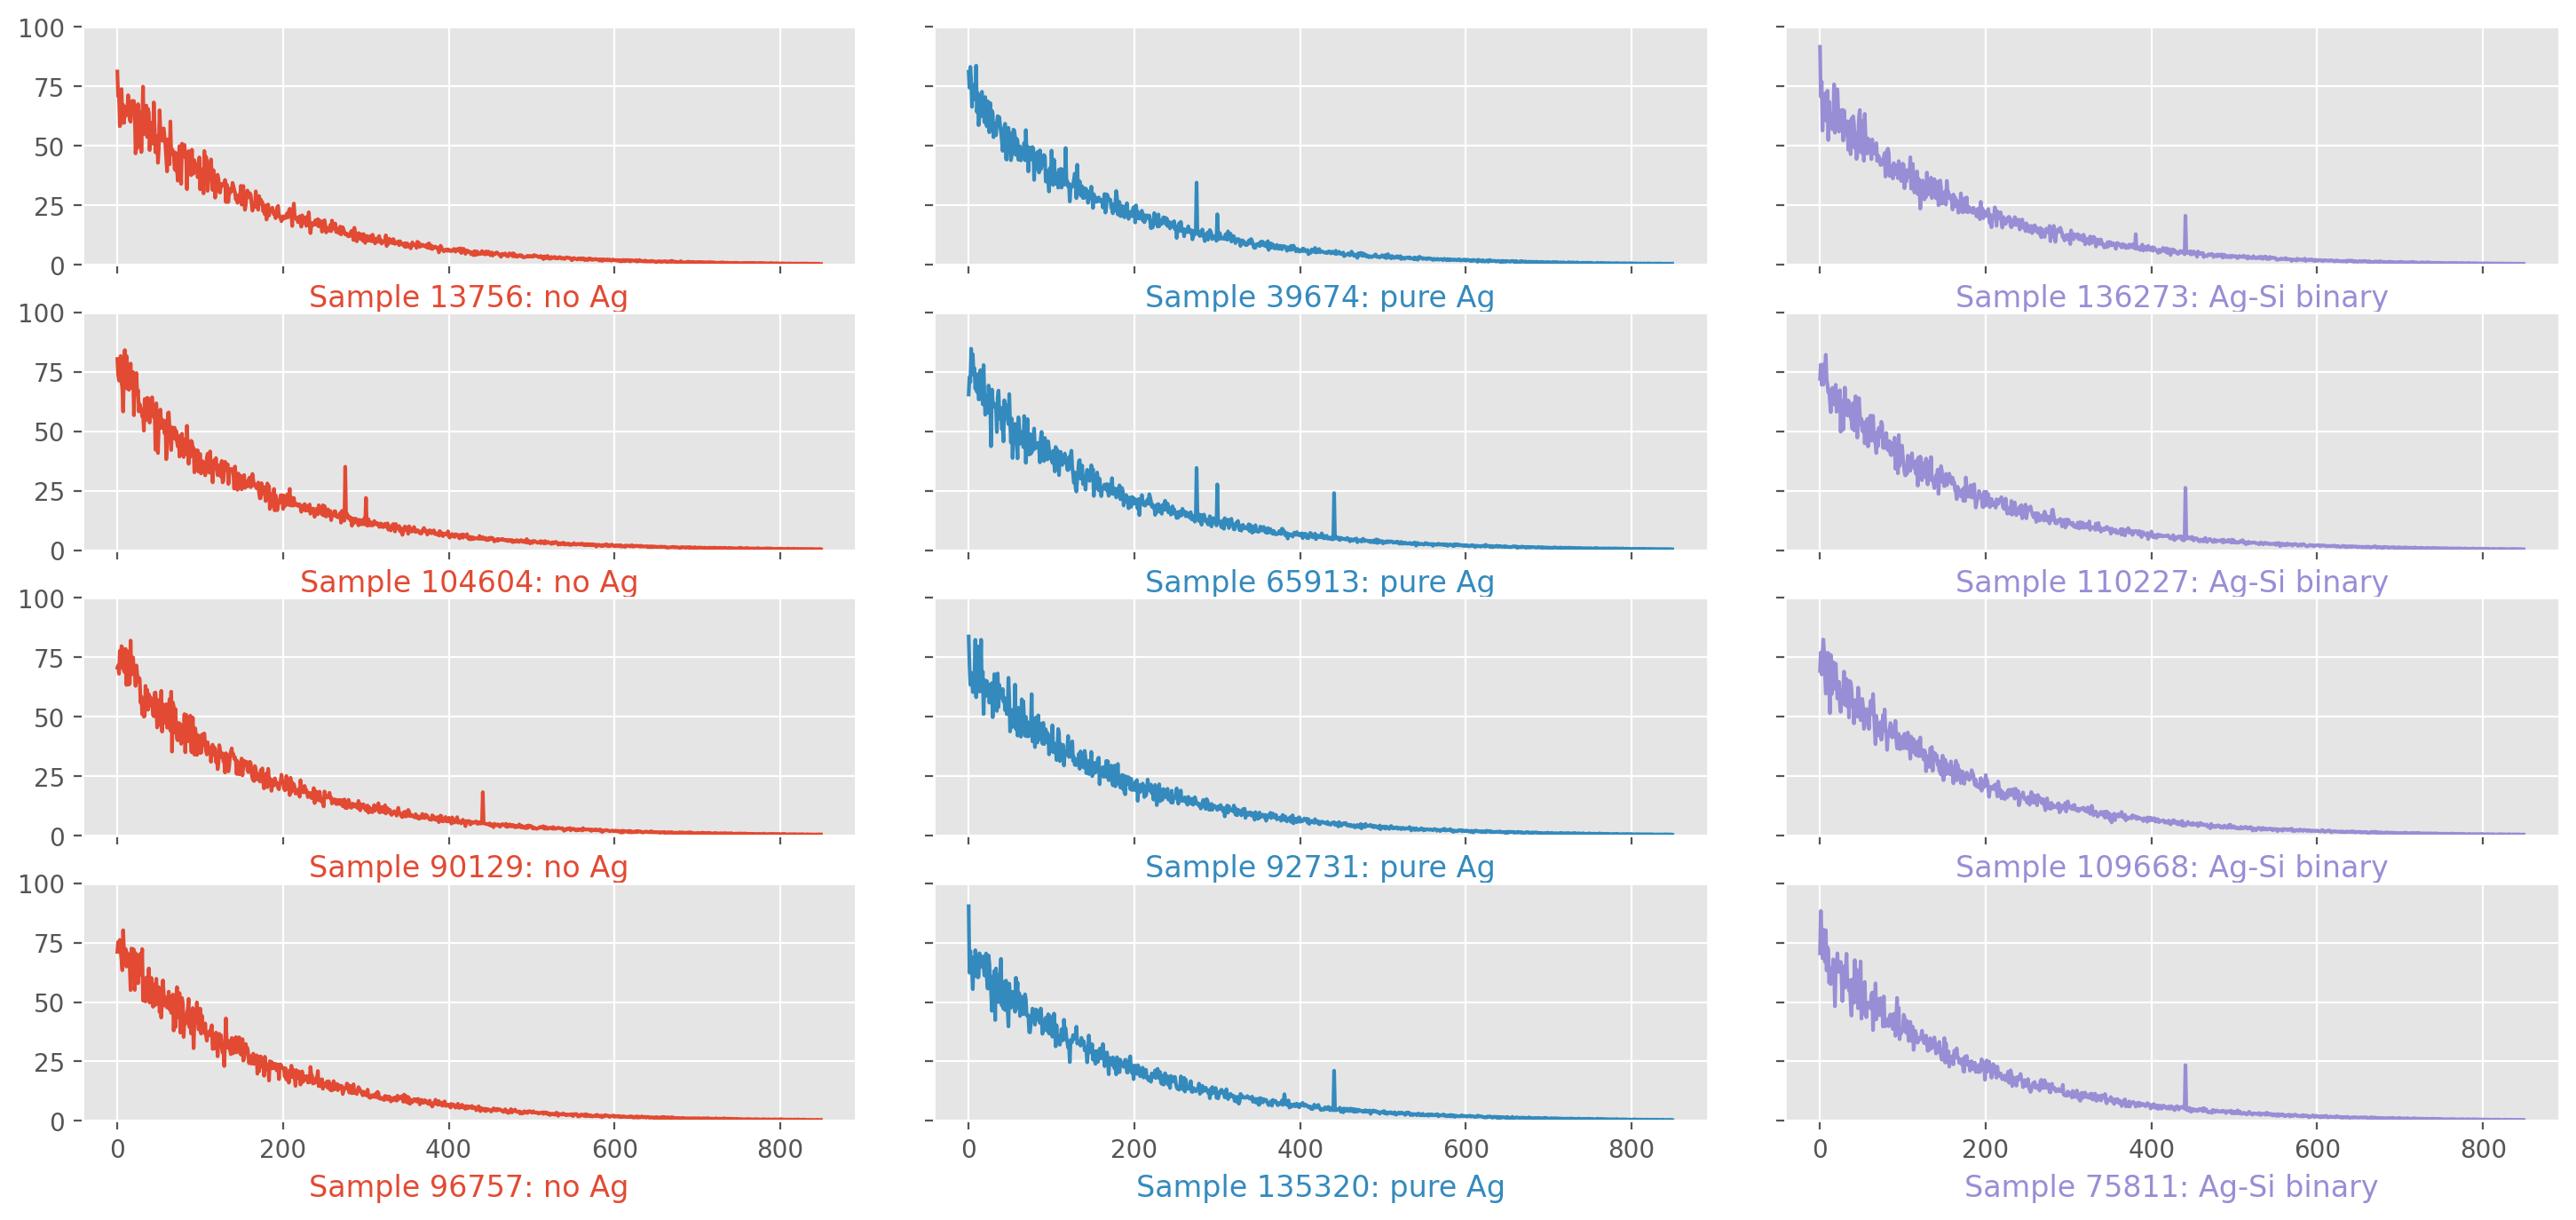

In [6]:
# Visualizing the data

conditions = [# no Ag
              ('no Ag', np.where(['Ag' not in elements for elements in data['Elements']])[0]),
              # pure Ag
              ('pure Ag', np.where([['Ag'] == elements for elements in data['Elements']])[0]),
              # Ag-Si
              ('Ag-Si binary', np.where([['Ag', 'Si'] == elements for elements in data['Elements']])[0])
             ]

# plot
ncond = len(conditions)
nplot = 4 # number of plots per condition
fig, axs = plt.subplots(nplot, ncond, dpi=200, figsize=(ncond * 6, nplot * 2), sharex=True, sharey=True)
plt.subplots_adjust(wspace=.1, hspace=.2)
for icond, cond in enumerate(conditions):
    for iplot, idata in enumerate(np.random.choice(cond[1], nplot)):
        # plot a part of the spectra (change if necessary)
        axs[iplot, icond].plot(data['Spectra'][idata][150:], c='C%d' % icond)
        axs[iplot, icond].set_xlabel('Sample %d: %s' % (idata, cond[0]), c='C%d' % icond)
        axs[iplot, icond].set_ylim(0, 100)

### Extracting Training & Testing Data
---

<div style="background-color: #f8f9fa; border-left: 5px solid #202124; padding: 14px; border-radius: 4px;">
  <p style="margin: 0; font-size: 15px; color: #3c4043;">
    <b>Pipeline Overview:</b> We will extract the raw features and convert our target compositions into a binary format suitable for neural network training, followed by spectrum normalization.
  </p>
</div>

<br>

* **Input Features ($X$):** The raw time-series data from the `Spectra` column.
* **Target Labels ($y$):** A binary **one-hot encoded vector**:
  * `[1, 0]` $\rightarrow$ **0:** No Silver ($\text{Ag}$) present
  * `[0, 1]` $\rightarrow$ **1:** Silver ($\text{Ag}$) present

> 💡 **Important Preprocessing Steps:**
> 1. **One-Hot Encoding:** Convert the "Elements" column into a 2D binary vector.
> 2. **Normalization:** Scale each individual spectrum $G(t)$ to lie strictly between **0 and 1** to ensure stable gradient descent during training.

In [7]:
data.head()

,Elements,Spectra
8877,"[Si, Fe, Sb, Bi]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 132.19327401887..."
88555,"[Sb, Fe, Bi]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 106.91719527298..."
111153,"[Si, Sb]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 108.04741040971..."
27279,"[Fe, Cu, Bi]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 106.84704457348..."
26419,"[Si, Fe]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 100.82180543319..."


In [8]:
# One-hot encode the presence of Ag

# A function to detect if 'Ag' exists in a list
def get_Ag_bool(list_obj):
    return 'Ag' in list_obj

# Perform One-hot encoding using the .apply() method of a Pandas Series
data['Ag_present'] = data['Elements'].apply(get_Ag_bool)

In [9]:
data

,Elements,Spectra,Ag_present
8877,"[Si, Fe, Sb, Bi]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 132.19327401887...",False
88555,"[Sb, Fe, Bi]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 106.91719527298...",False
111153,"[Si, Sb]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 108.04741040971...",False
27279,"[Fe, Cu, Bi]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 106.84704457348...",False
26419,"[Si, Fe]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 100.82180543319...",False
...,...,...,...
97215,[Zn],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 132.70109581422...",False
53218,"[Zn, Bi]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 150.03242472390...",False
11163,"[Si, Sb, Zn]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 117.03402088125...",False
67137,"[Zn, Cu]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 127.40998449939...",False


# Reorganize the data to keep only the features (Spectra) and targets (Presence or absence of Ag)

In [10]:
data_ = data.copy()
data = data_[['Ag_present', 'Spectra']]
data.head()

,Ag_present,Spectra
8877,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 132.19327401887..."
88555,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 106.91719527298..."
111153,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 108.04741040971..."
27279,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 106.84704457348..."
26419,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 100.82180543319..."


Split the data into test and train with a 80:20 ratio

In [11]:
from sklearn.model_selection import train_test_split

data_train, data_test = train_test_split(data, test_size=0.2, random_state=25)

In [12]:
#Extract features (X) and labels (Y) for test and train data

X_train = data_train['Spectra']
y_train = data_train['Ag_present']

X_test = data_test['Spectra']
y_test = data_test['Ag_present']

In [13]:
X_train

,Spectra
56186,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 126.56649154332..."
17696,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 122.98487254433..."
27794,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 121.30112589801..."
4396,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 119.00878292681..."
72260,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 119.85339753626..."
...,...
23183,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 139.17709355420..."
13007,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 130.32960710528..."
137901,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 114.86523191028..."
25179,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 125.26170089790..."


In this problem, every point in X (110890x1) contains an array/vector  and not a single scalar valued number. We normalize the entries and convert it into matrix form.

In [14]:
# Let us first check dimensionality of all the arrays (spectra) in the dataset

def find_shape(x):
  return np.shape(x)

data['Spectra'].apply(find_shape)


,Spectra
8877,"(1000,)"
88555,"(1000,)"
111153,"(1000,)"
27279,"(1000,)"
26419,"(1000,)"
...,...
97215,"(1000,)"
53218,"(1000,)"
11163,"(1000,)"
67137,"(1000,)"


In [15]:
# Let us now check if all the arrays are of identical dimension

def find_shape(x):
  return np.shape(x)

data['Spectra'].apply(find_shape).unique()


array([(1000,)], dtype=object)

In [99]:
# Normalize the entries of Spectra between 0-1
def get_array_from_X(X):
    training_list = []

    for row in X.iterrows():
        training_list.append(row[1]['Spectra']/np.max(row[1]['Spectra']))

    return np.array(training_list)

In [17]:
# convert the training features into numpy matrix (with normalization)
X_train_ = X_train.copy()
X_train = get_array_from_X(X_train)

In [18]:
X_train_.shape

(110890,)

In [19]:
X_train.shape

(110890, 1000)

In [20]:
X_train_

,Spectra
56186,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 126.56649154332..."
17696,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 122.98487254433..."
27794,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 121.30112589801..."
4396,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 119.00878292681..."
72260,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 119.85339753626..."
...,...
23183,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 139.17709355420..."
13007,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 130.32960710528..."
137901,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 114.86523191028..."
25179,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 125.26170089790..."


In [21]:
X_train

array([[0.        , 0.        , 0.        , ..., 0.00051047, 0.00065395,
        0.00068291],
       [0.        , 0.        , 0.        , ..., 0.00080208, 0.0007081 ,
        0.0006735 ],
       [0.        , 0.        , 0.        , ..., 0.00071371, 0.00064806,
        0.00059421],
       ...,
       [0.        , 0.        , 0.        , ..., 0.00054271, 0.00063313,
        0.00068073],
       [0.        , 0.        , 0.        , ..., 0.00065125, 0.00065931,
        0.00055792],
       [0.        , 0.        , 0.        , ..., 0.00057093, 0.00072424,
        0.00062886]])

In [22]:
# convert the testing features into numpy matrix (with normalization)
X_test_ = X_test.copy()
X_test = get_array_from_X(X_test)

In [23]:
X_test_

,Spectra
71884,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 100.06611666922..."
67569,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 114.72922348989..."
45842,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 105.30970189499..."
4895,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 122.50049389764..."
25876,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 115.42819168362..."
...,...
1812,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 104.40743207246..."
67423,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 128.28912350968..."
19889,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 132.70642026013..."
101058,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 117.83137231637..."


In [24]:
X_test.shape

(27723, 1000)

In [33]:
# Set a seed
tf.keras.utils.set_random_seed(15)

In [34]:
# Create an instance of the Multi Layer Perceptron
mlp_model = tf.keras.Sequential

In [35]:
# add input layer
mlp_model.add(tf.keras.layers.InputLayer(shape = (1000,), name = 'Input Layer', ))

Visualize the 1000 neurons

In [36]:
# Let us construct hidden layer with 512 neurons, with the activation function being reLu
mlp_model.add(tf.keras.layers.Dense(units = 512, activation = tf.keras.activations.relu, name = 'hidden_layer_1'))

# If you want to add another hidden layer with say 16 neurons, use the same synatax as the above line of code.
#mlp_model.add(tf.keras.layers.Dense(units = 16, activation = tf.keras.activations.relu, name = 'hidden_layer_2'))

In [37]:
# Add output layer: Only one neuron, since we need a binary output
mlp_model.add(tf.keras.layers.Dense(units = 1, activation = tf.keras.activations.sigmoid, name = 'output_layer'))

In [38]:
# Compile the model
mlp_model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=0.01), loss = tf.keras.losses.BinaryCrossentropy(),
                  metrics=['accuracy'])

In [39]:
# save the untrained weights and baises
mlp_model.save('untrained_model.keras')

In [40]:
# get a summary of the MLP
mlp_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 512)            │       512,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513,025 (1.96 MB)

 Trainable params: 513,025 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Let us now train the model. We choose 60 epochs for training

In [43]:
history = mlp_model.fit(X_train, y_train, batch_size=512, epochs=60, validation_split=0.2)

Epoch 1/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9303 - loss: 0.1854 - val_accuracy: 0.9307 - val_loss: 0.1588
Epoch 2/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9291 - loss: 0.2226 - val_accuracy: 0.9269 - val_loss: 0.2370
Epoch 3/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9280 - loss: 0.2018 - val_accuracy: 0.9276 - val_loss: 0.1896
Epoch 4/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9297 - loss: 0.1816 - val_accuracy: 0.9294 - val_loss: 0.1644
Epoch 5/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9295 - loss: 0.2045 - val_accuracy: 0.9269 - val_loss: 0.1948
Epoch 6/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9301 - loss: 0.1764 - val_accuracy: 0.9288 - val_loss: 0.1633
Epoch 7/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9314 - loss: 0.2002 - val_accuracy: 0.9269 - val_loss: 0.2076
Epoch 8/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9276 - loss: 0.1990 - val_acc

Text(0.5, 0, 'Epochs')

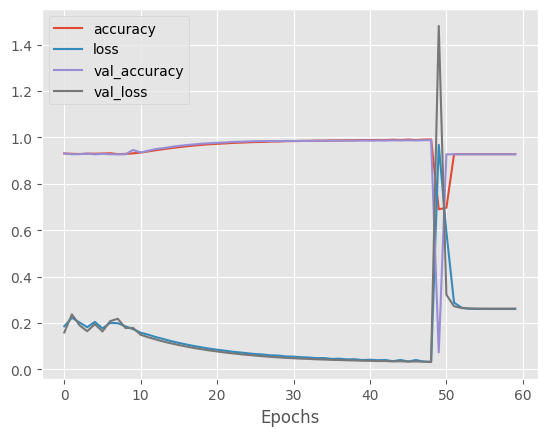

In [44]:
# plot the training history
pd.DataFrame(history.history).plot()
plt.xlabel('Epochs')

In [46]:
# Demonstration of Early Stopping, and using random 20% for validation set instead of default last 20% of the training set

In [69]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=15)

In [70]:
# load the untrained model
mlp_model_new = tf.keras.models.load_model('./untrained_model.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [71]:
# check the compilation configuration of the new model
mlp_model_new.get_compile_config()

{'optimizer': {'module': 'keras.optimizers',
  'class_name': 'Adam',
  'config': {'name': 'adam',
   'learning_rate': 0.009999999776482582,
   'weight_decay': None,
   'clipnorm': None,
   'global_clipnorm': None,
   'clipvalue': None,
   'use_ema': False,
   'ema_momentum': 0.99,
   'ema_overwrite_frequency': None,
   'loss_scale_factor': None,
   'gradient_accumulation_steps': None,
   'beta_1': 0.9,
   'beta_2': 0.999,
   'epsilon': 1e-07,
   'amsgrad': False},
  'registered_name': None},
 'loss': {'module': 'keras.losses',
  'class_name': 'BinaryCrossentropy',
  'config': {'name': 'binary_crossentropy',
   'reduction': 'sum_over_batch_size',
   'from_logits': False,
   'label_smoothing': 0.0,
   'axis': -1},
  'registered_name': None},
 'loss_weights': None,
 'metrics': ['accuracy'],
 'weighted_metrics': None,
 'run_eagerly': False,
 'steps_per_execution': 1,
 'jit_compile': False}

In [72]:
# create a checkpoint to save the model with best weights.
checkpoint = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

In [74]:
# Train the model using early stopping
history_2 = mlp_model_new.fit(X_train, y_train, epochs = 30, batch_size = 512, validation_data=(X_val, y_val), callbacks=[checkpoint])

Epoch 1/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9291 - loss: 0.2838 - val_accuracy: 0.9226 - val_loss: 0.2740
Epoch 2/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9291 - loss: 0.2565 - val_accuracy: 0.9226 - val_loss: 0.2737
Epoch 3/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9291 - loss: 0.2559 - val_accuracy: 0.9226 - val_loss: 0.2720
Epoch 4/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9291 - loss: 0.2552 - val_accuracy: 0.9226 - val_loss: 0.2723
Epoch 5/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9291 - loss: 0.2542 - val_accuracy: 0.9226 - val_loss: 0.2701
Epoch 6/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9291 - loss: 0.2510 - val_accuracy: 0.9226 - val_loss: 0.2668
Epoch 7/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9291 - loss: 0.2491 - val_accuracy: 0.9226 - val_loss: 0.2745
Epoch 8/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9291 - loss: 0.2465 - val_accu

Text(0.5, 0, 'Epochs')

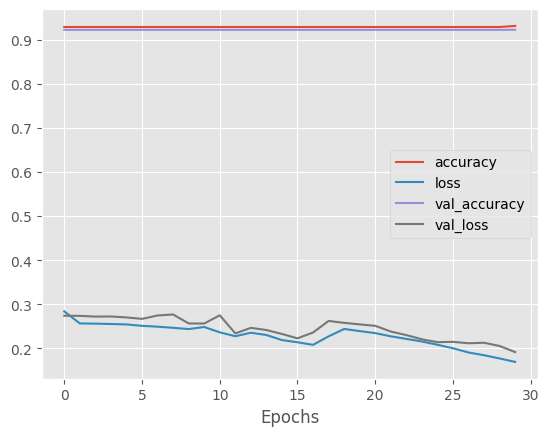

In [75]:
pd.DataFrame(history_2.history).plot()
plt.xlabel('Epochs')

In [77]:
#Problem: Starting accuracy is very high, right from 1st epoch

In [78]:
# Let us inspect the data distribution

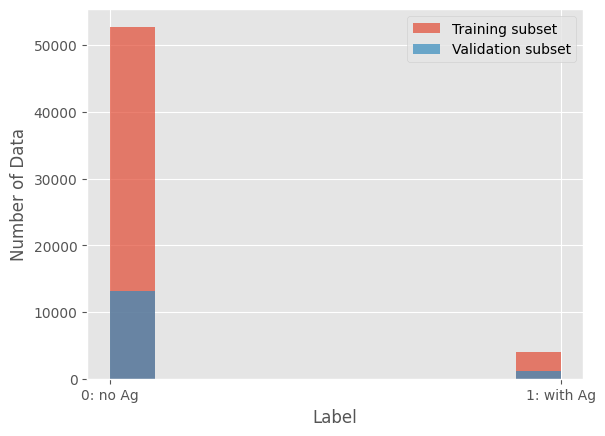

In [83]:
import matplotlib.pyplot as plt

plt.figure(dpi=100)

# Cast boolean values (True/False) to integers (1/0)
plt.hist(y_train.astype(int), label='Training subset', alpha=0.7)
plt.hist(y_val.astype(int), label='Validation subset', alpha=0.7)

plt.xticks([0, 1], ['0: no Ag', '1: with Ag'])
plt.xlabel('Label')
plt.ylabel('Number of Data')
plt.legend()
plt.show()

The histograms show that our dataset is dominated by samples labelled 0 or "no Ag", which account for over 95% of the data. Thus, if the model simply learns to *guess* "no Ag" in every sample, it can achieve 95% accuracy without learning anything meaningful. This problem is known as **class imbalance**.

To avoid this, we must balance the classes. There are a number of strategies we can take:

* Upsample the minority class;
* Downsample the majority class;
* Change the performance metric.

The best available option for our problem is to downsample the majority class, which can be easily achieved with `numpy`/`pandas`:

In [86]:
data['Ag_present']

,Ag_present
8877,False
88555,False
111153,False
27279,False
26419,False
...,...
97215,False
53218,False
11163,False
67137,False


In [87]:
data[data['Ag_present']]

,Ag_present,Spectra
135979,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 121.21197123935..."
136622,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 129.12771121808..."
136220,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 114.88835355088..."
134426,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 115.77538867145..."
135859,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 127.00562037169..."
...,...,...
134286,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 114.57997596709..."
130264,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 133.88357951525..."
130296,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 116.09168273058..."
138519,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 132.15145721115..."


In [88]:
#Find the original indices of 0 (no Ag) and 1 (with Ag) and seperate them
data_with_Ag = data[data['Ag_present'] == True]
data_without_Ag = data[data['Ag_present'] == False]

In [90]:
# randomly sample as many datapoints with Ag as there are datapoints without Ag
random_indices = np.random.choice(data_without_Ag.index.values, size=len(data_with_Ag))
downsampled_data_without_Ag = data_without_Ag.loc[random_indices]

In [92]:
#Now concatenate with and without Ag data points
downsampled_data = pd.concat([data_with_Ag, downsampled_data_without_Ag], axis=0)

In [93]:
downsampled_data

,Ag_present,Spectra
135979,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 121.21197123935..."
136622,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 129.12771121808..."
136220,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 114.88835355088..."
134426,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 115.77538867145..."
135859,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 127.00562037169..."
...,...,...
15875,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 108.42295254613..."
76335,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 98.917594609016..."
84236,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 139.52423538231..."
35977,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 97.959112542981..."


In [94]:
# Split the downsampled data into 80:20 training:validation sets
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(downsampled_data[['Spectra']], downsampled_data[['Ag_present']],
                                                  test_size=0.2, random_state=15)

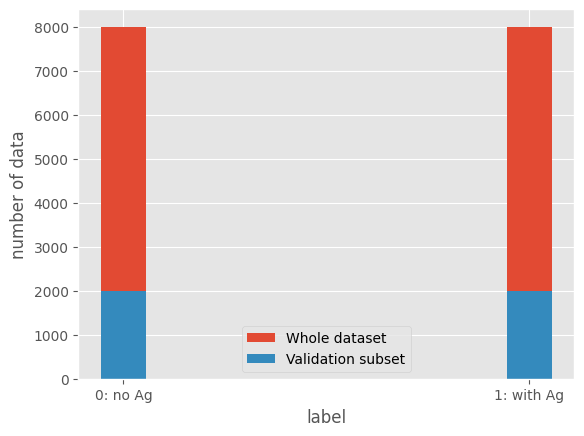

In [95]:
# plot distribution of data
plt.figure(dpi=100)
plt.hist(y_train_b['Ag_present'].apply(lambda x: int(x)).values, label='Whole dataset')
plt.hist(y_val_b['Ag_present'].apply(lambda x: int(x)).values, label='Validation subset')
plt.xticks([0.05, 0.95], ['0: no Ag', '1: with Ag'])
plt.xlabel('label')
plt.ylabel('number of data')
plt.legend()
plt.show()

In [96]:
# Re-train the model with the balanced dataset

In [100]:
# Convert training and validation features into numpy arrays
X_train_b_ = X_train_b.copy()
X_train_b = get_array_from_X(X_train_b)

X_val_b_ = X_val_b.copy()
X_val_b = get_array_from_X(X_val_b)

In [126]:
# Let us now do the same MLP building, training and validation exercise as before
MLP_balanced = tf.keras.models.load_model("./untrained_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [127]:
MLP_balanced.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss=tf.keras.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [128]:
MLP_balanced.get_compile_config()

{'optimizer': {'module': 'keras.optimizers',
  'class_name': 'Adam',
  'config': {'name': 'adam',
   'learning_rate': 9.999999747378752e-05,
   'weight_decay': None,
   'clipnorm': None,
   'global_clipnorm': None,
   'clipvalue': None,
   'use_ema': False,
   'ema_momentum': 0.99,
   'ema_overwrite_frequency': None,
   'loss_scale_factor': None,
   'gradient_accumulation_steps': None,
   'beta_1': 0.9,
   'beta_2': 0.999,
   'epsilon': 1e-07,
   'amsgrad': False},
  'registered_name': None},
 'loss': {'module': 'keras.losses',
  'class_name': 'BinaryCrossentropy',
  'config': {'name': 'binary_crossentropy',
   'reduction': 'sum_over_batch_size',
   'from_logits': False,
   'label_smoothing': 0.0,
   'axis': -1},
  'registered_name': None},
 'loss_weights': None,
 'metrics': ['accuracy'],
 'weighted_metrics': None,
 'run_eagerly': False,
 'steps_per_execution': 1,
 'jit_compile': False}

In [129]:
MLP_balanced.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 512)            │       512,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513,025 (1.96 MB)

 Trainable params: 513,025 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

In [131]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
history_b = MLP_balanced.fit(X_train_b, y_train_b, epochs=1000, batch_size=512, validation_data=(X_val_b, y_val_b), callbacks=[early_stopping_cb])

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6557 - loss: 0.6586 - val_accuracy: 0.6645 - val_loss: 0.6613
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6581 - loss: 0.6580 - val_accuracy: 0.6643 - val_loss: 0.6608
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6594 - loss: 0.6574 - val_accuracy: 0.6635 - val_loss: 0.6602
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6619 - loss: 0.6568 - val_accuracy: 0.6645 - val_loss: 0.6597
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6639 - loss: 0.6562 - val_accuracy: 0.6658 - val_loss: 0.6591
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6656 - loss: 0.6555 - val_accuracy: 0.6653 - val_loss: 0.6586
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6661 - loss: 0.6549 - val_accuracy: 0.6650 - val_loss: 0.6580
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6674 - loss: 0.6543 - val_accu

Text(0.5, 0, 'Epochs')

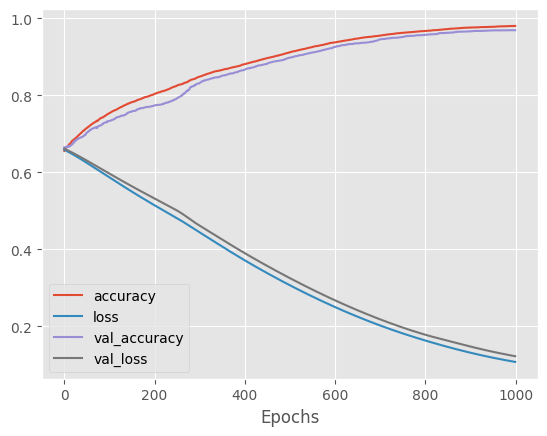

In [132]:
# plot the training history
pd.DataFrame(history_b.history).plot()
plt.xlabel('Epochs')

In [134]:
MLP_balanced.save('./best_MLP_Ag_detection.keras')

In [136]:
# Evaluate the best model performance on the testing data

# Get the test data
final_test_data = data[pd.Series(data.index).apply(lambda x: x not in downsampled_data.index.values)]

/tmp/ipykernel_6003/2437636505.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  final_test_data = data[pd.Series(data.index).apply(lambda x: x not in downsampled_data.index.values)]


In [137]:
final_test_data.head(5)

,Ag_present,Spectra
8877,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 132.19327401887..."
88555,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 106.91719527298..."
111153,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 108.04741040971..."
26419,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 100.82180543319..."
60986,False,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 122.69590097743..."


In [138]:
# Get X_test_final and y_test_final (remove .iloc[10000] to consider all the test data for evaluation)
X_test_final = get_array_from_X(final_test_data[['Spectra']].iloc[:10000])
y_test_final = final_test_data[['Ag_present']].iloc[:10000]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


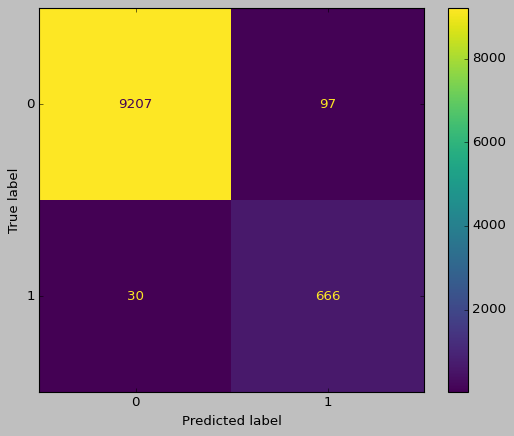

In [140]:
# Create a confusion matrix for the first 10000 test data
y_pred = MLP_balanced.predict(X_test_final)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
conf_mat = confusion_matrix(y_test_final.values.flatten(), y_pred.round().flatten())

# Plot the confusion matrix
conf_mat_disp = ConfusionMatrixDisplay(conf_mat)
plt.style.use('classic')
conf_mat_disp.plot()